[PHOENIX GRID CREATOR] : phoenix wavelength grid found & loaded in
[4000.] K


loading in spectra...: 100%|██████████| 1/1 [00:00<00:00, 33.49it/s]

4000.0 K
0.5 dex
3.0 dex
22499.875000000004


1.708398688305914 um
0.10101854463442361 Jy


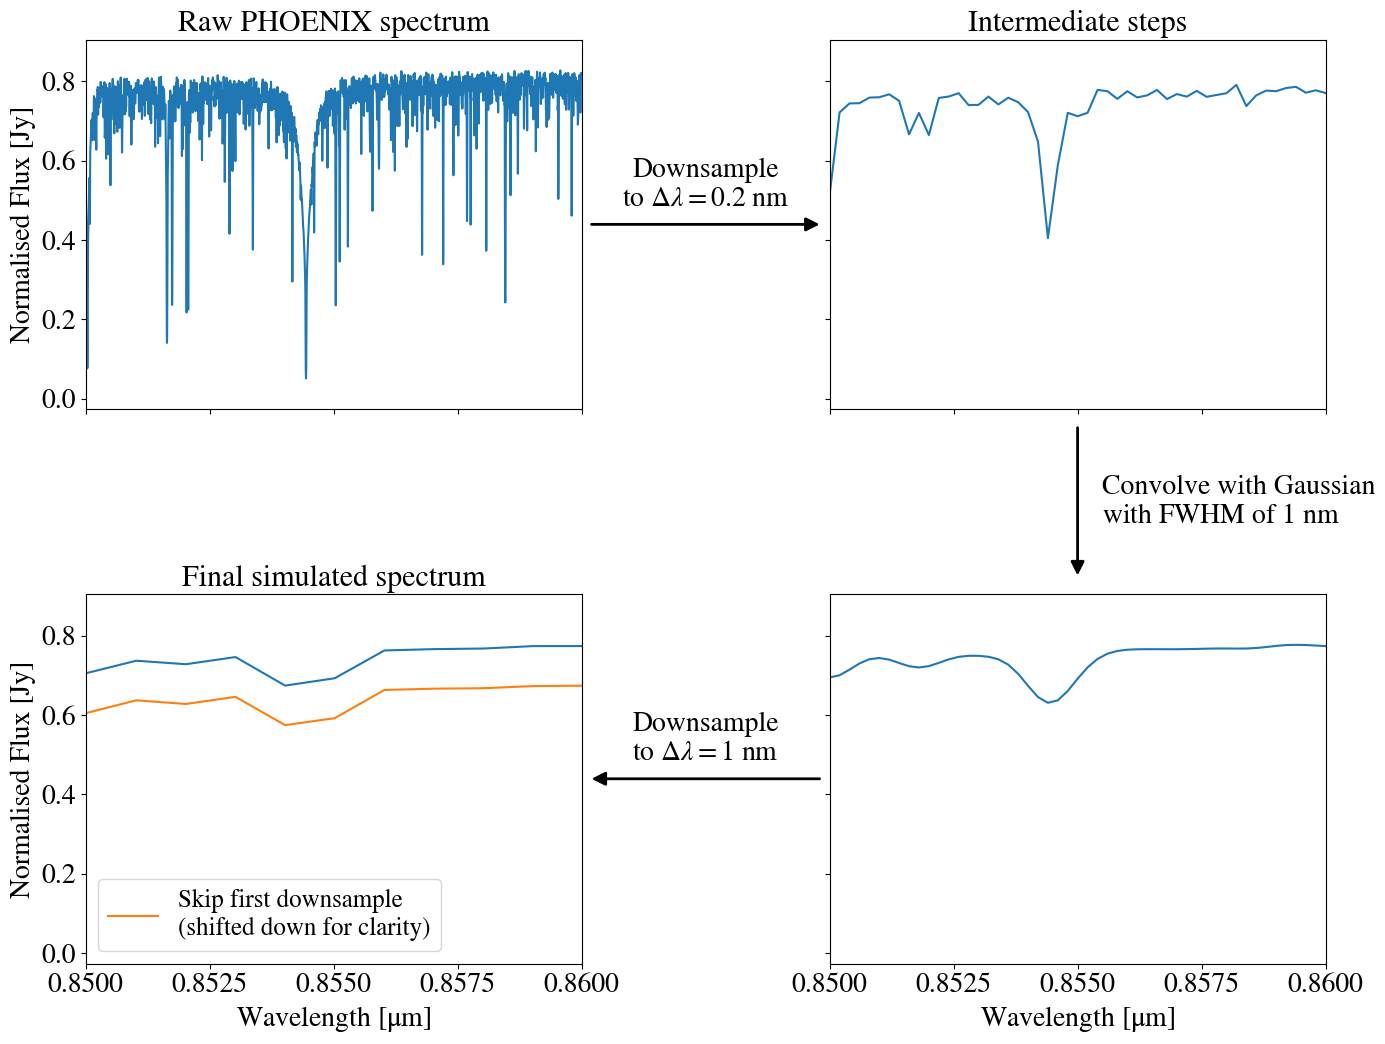

In [ ]:
from constants import *
from astropy import units as u
from phoenix_grid_creator.spectral_grid import spectral_grid
from spectrum_component_analyser.phoenix_spectrum import phoenix_spectrum
from matplotlib import pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter1d
from spectrum_component_analyser.spectrum import DEFAULT_FLUX_UNIT
from pathlib import Path
from astropy.visualization import quantity_support
import spectres

quantity_support()

x_min, x_max = 0.85 * u.um, 0.86 * u.um
# x_min, x_max = 1.6 * u.um, 1.8 * u.um

fits_file_paths = list(Path(package_path / "raw_phoenix_spectra").rglob("*.fits"))

raw_spec_grid = spectral_grid.from_local_raw(files=fits_file_paths[300:300+1], observational_wavelengths=None, parallelise=False)
raw_spec_grid.Wavelengths = raw_spec_grid.Wavelengths.to(u.um)
raw_spec_grid.Fluxes *= u.Jy

example_spectrum = raw_spec_grid.get_spectrum(raw_spec_grid.T_effs[0], raw_spec_grid.FeHs[0], raw_spec_grid.Log_gs[0])

print(example_spectrum.T_eff)
print(example_spectrum.FeH)
print(example_spectrum.Log_g)

fig, ax = plt.subplots(2, 2, figsize=(16, 12), sharex=True, sharey=True)

# plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({'font.size': 18})
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIXGeneral"],
    "mathtext.fontset": "stix",
})


# CORRECT WORKFLOW

ax[0, 0].plot(example_spectrum.Wavelengths, example_spectrum.Fluxes)
ax[0, 0].set_xlim(x_min, x_max)
ax[0, 0].set_title("Raw PHOENIX spectrum")

desired_resolution = 0.001 * u.um
safe_downsample_resolution = desired_resolution / 5

n_pts = ((example_spectrum.Wavelengths.max() - example_spectrum.Wavelengths.min()) / safe_downsample_resolution).to(u.dimensionless_unscaled).value
print(n_pts)
wave_safe_downsample = np.linspace(example_spectrum.Wavelengths.min(), example_spectrum.Wavelengths.max(), int(np.ceil(n_pts)))
flux_safe_downsample = spectres.spectres(wave_safe_downsample.value, example_spectrum.Wavelengths.value, example_spectrum.Fluxes.value) * example_spectrum.Fluxes.unit

ax[0, 1].plot(wave_safe_downsample, flux_safe_downsample)
ax[0, 1].set_xlim(x_min, x_max)
ax[0, 1].set_title("Intermediate steps")

# The physical width of the FWHM expressed as a number of grid points
fwhm_pix = (desired_resolution / safe_downsample_resolution).to(u.dimensionless_unscaled).value
sigma = fwhm_pix / (2 * np.sqrt(2 * np.log(2)))

convolved_flux = gaussian_filter1d(flux_safe_downsample.value, sigma, mode="nearest") * flux_safe_downsample.unit

ax[1, 1].plot(wave_safe_downsample, convolved_flux)
ax[1, 1].set_xlim(x_min, x_max)
# ax[1, 1].set_title("Gaussian Convolved")

desired_points = (example_spectrum.Wavelengths.max() - example_spectrum.Wavelengths.min()) / desired_resolution
desired_points = int(desired_points.to(u.dimensionless_unscaled).value)
wave_desired = np.linspace(example_spectrum.Wavelengths.min(), example_spectrum.Wavelengths.max(), desired_points)
# new_flux = np.interp(wave_desired.value, wave_uniform.value, convolved_flux.value)
# new_flux *= DEFAULT_FLUX_UNIT
new_flux = spectres.spectres(wave_desired.value, wave_safe_downsample.value, convolved_flux.value) * convolved_flux.unit

ax[1, 0].plot(wave_desired, new_flux)
ax[1, 0].set_xlim(x_min, x_max)
ax[1, 0].set_title("Final simulated spectrum")

# INEFFICIENT WORKFLOW

dlambda = np.min(np.abs(np.diff(example_spectrum.Wavelengths))) # convolve to highest resolution present
fwhm_pix = (desired_resolution / dlambda).to(u.dimensionless_unscaled).value
sigma = fwhm_pix / (2 * np.sqrt(2 * np.log(2)))
inefficient_convolved_flux = gaussian_filter1d(example_spectrum.Fluxes.value, sigma, mode="nearest") * example_spectrum.Fluxes.unit

inefficient_final_flux = spectres.spectres(wave_desired.value, example_spectrum.Wavelengths.value, inefficient_convolved_flux.value) * inefficient_convolved_flux.unit

mask = np.where(np.isfinite(new_flux.value))
d = np.argmax(np.abs(inefficient_final_flux[mask] - new_flux[mask]))
print(wave_desired[d])
print(np.max(np.abs(inefficient_final_flux[mask] - new_flux[mask])))

inefficient_final_flux -= 0.1 * u.Jy
ax[1, 0].plot(wave_desired, inefficient_final_flux, label="Skip first downsample\n(shifted down for clarity)")
ax[1, 0].legend()

ax[1, 0].set_xlabel("Wavelength [$\mathrm{\mu}$m]")
ax[1, 0].set_ylabel("Normalised Flux [Jy]")
ax[0, 0].set_ylabel("Normalised Flux [Jy]")
ax[1, 1].set_xlabel("Wavelength [$\mathrm{\mu}$m]")

# ARROWS

plt.rcParams.update({'font.size': 20})


from matplotlib.patches import ConnectionPatch

arrow_props = dict(arrowstyle='-|>', lw=2, color='black', mutation_scale=20)

cp1 = ConnectionPatch(xyA=(1.02, 0.5), xyB=(-0.02, 0.5), 
                      coordsA="axes fraction", coordsB="axes fraction",
                      axesA=ax[0, 0], axesB=ax[0, 1], **arrow_props)
fig.add_artist(cp1)
ax[0, 0].text(1.25, 0.55, 'Downsample\nto $\Delta \lambda = 0.2$ nm', transform=ax[0, 0].transAxes, 
              fontweight='medium', ha='center')

cp2 = ConnectionPatch(xyA=(0.5, -0.05), xyB=(0.5, 1.05), 
                      coordsA="axes fraction", coordsB="axes fraction",
                      axesA=ax[0, 1], axesB=ax[1, 1], **arrow_props)
fig.add_artist(cp2)
ax[0, 1].text(0.55, -0.25, f'Convolve with Gaussian\nwith FWHM of $1$ nm', transform=ax[0, 1].transAxes, 
              fontweight='medium', rotation=0, va='center')

cp3 = ConnectionPatch(xyA=(-0.02, 0.5), xyB=(1.02, 0.5), 
                      coordsA="axes fraction", coordsB="axes fraction",
                      axesA=ax[1, 1], axesB=ax[1, 0], **arrow_props)
fig.add_artist(cp3)
ax[1, 1].text(1.25, 0.55, f'Downsample\nto $\Delta \lambda = 1$ nm', transform=ax[1, 0].transAxes, 
              fontweight='medium', ha='center')





global_ymin = np.inf
global_ymax = -np.inf

for axis in ax.flat:
    for line in axis.get_lines():
        x_data = line.get_xdata()
        y_data = line.get_ydata()

        mask = (x_data >= x_min) & (x_data <= x_max)
        if np.any(mask):
            visible_y = y_data[mask]
            global_ymin = min(global_ymin, np.min(visible_y))
            global_ymax = max(global_ymax, np.max(visible_y))

margin = (global_ymax - global_ymin) * 0.1
final_ylim = (global_ymin - margin, global_ymax + margin)

for axis in ax.flat:
    axis.set_ylim(final_ylim)


fig.subplots_adjust(wspace=.5, hspace=.5)
plt.savefig("wavelength_downsampling_procedure.svg", bbox_inches='tight', pad_inches=0.5)

# plt.tight_layout()
plt.show()